In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [2]:
# parameter setting
batch_size = 32
learning_rate = 0.001
epoch = 15

# GPU setting
cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')

print('Current cuda device is', device)

Current cuda device is cuda


In [3]:
# dataset 불러오기
train_data = datasets.MNIST(root='./data/train/',
                            train=True,
                            transform=transforms.ToTensor(),
                            download=True)
test_data = datasets.MNIST(root='./data/test/',
                           train=False,
                           transform=transforms.ToTensor(),
                           download=True)

train_loader = DataLoader(dataset=train_data,
                          batch_size=batch_size,
                          shuffle=True)
test_loader = DataLoader(dataset=test_data,
                         batch_size=batch_size,
                         shuffle=False)

In [4]:
# Deep Learning Model setting
class Convolution_Neural_Networks(nn.Module):
  def __init__(self):
    super(Convolution_Neural_Networks, self).__init__()
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, stride = 1, padding = 'same')
    self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 'same')
    self.dropout = nn.Dropout2d(0.25) # eval() 에서 적용 X
    self.relu = nn.ReLU()
    self.max_pooling = nn.MaxPool2d(kernel_size = 2)
    self.fc1 = nn.Linear(3136, 1000) # 7 * 7 * 64 = 3136
    self.fc2 = nn.Linear(1000, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.max_pooling(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.max_pooling(x)

    x = self.dropout(x)
    x = torch.flatten(x, 1)

    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    output = F.log_softmax(x, dim = 1)
    return output

In [5]:
# model에 GPU 적용
model = Convolution_Neural_Networks().cuda(device)
# model에 CPU 적용
# model = Convolution_Neural_Networks().cpu()

optimizer = optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

Train step : 1000	Loss : 0.021065
Train step : 2000	Loss : 0.009174
Train step : 3000	Loss : 0.026444
Train step : 4000	Loss : 0.002121
Train step : 5000	Loss : 0.033717
Train step : 6000	Loss : 0.003731
Train step : 7000	Loss : 0.000184
Train step : 8000	Loss : 0.053341
Train step : 9000	Loss : 0.011756
Train step : 10000	Loss : 0.000418
Train step : 11000	Loss : 0.016474
Train step : 12000	Loss : 0.019491
Train step : 13000	Loss : 0.005626
Train step : 14000	Loss : 0.000918
Train step : 15000	Loss : 0.000168
Train step : 16000	Loss : 0.000206
Train step : 17000	Loss : 0.000111
Train step : 18000	Loss : 0.000007
Train step : 19000	Loss : 0.001214
Train step : 20000	Loss : 0.014283
Train step : 21000	Loss : 0.000001
Train step : 22000	Loss : 0.000550
Train step : 23000	Loss : 0.020430
Train step : 24000	Loss : 0.000540
Train step : 25000	Loss : 0.000013
Train step : 26000	Loss : 0.000015
Train step : 27000	Loss : 0.000000
Train step : 28000	Loss : 0.006579


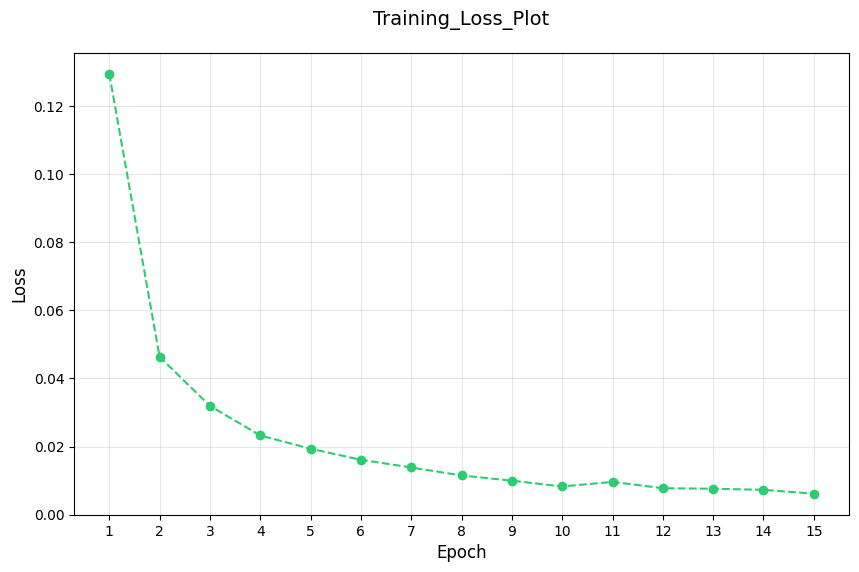

In [6]:
train_losses = []

# Train
i = 1
for epoch in range(epoch):
  running_loss = 0.0  # Epoch 별 Loss 누적 변수
  for data, target in train_loader:
      data = data.to(device)
      target = target.to(device)
      optimizer.zero_grad()
      output = model(data)
      loss = criterion(output, target)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()  # Batch Loss 누적
      if i % 1000 == 0:
        print("Train step : {}\tLoss : {:3f}".format(i, loss.item()))
      i += 1

  # Epoch 종료 시 평균 Loss 및 기록
  epoch_loss = running_loss / len(train_loader)
  train_losses.append(epoch_loss)

# Training Loss 시각화
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_losses)+1), train_losses,
         marker='o', linestyle='--', color='#2ecc71')
plt.title('Training_Loss_Plot', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, len(train_losses)+1))
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Test
model.eval()
correct = 0

# 각 숫자별 정답 카운트를 위한 리스트 초기화 (0~9)
correct_per_digit = [0] * 10  # 수정: [0]으로 초기화
total_per_digit = [0] * 10    # 수정: [0]으로 초기화

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        prediction = output.data.max(1)[1]
        correct += prediction.eq(target.data).sum()

        # 각 숫자별 정확도 계산
        for i in range(len(target)):
            digit = target[i].item()  # 실제 label 값(0~9)
            total_per_digit[digit] += 1
            if prediction[i] == target[i]:
                correct_per_digit[digit] += 1

# 숫자별 인식률 계산
print("\n[각 숫자별 인식률]")
for digit in range(10):
    accuracy = 100 * correct_per_digit[digit] / total_per_digit[digit]
    print(f'{digit}: {accuracy:.2f}% ({correct_per_digit[digit]}/{total_per_digit[digit]})')

# 전체 정확도 출력
print('\n[전체 테스트 정확도]')
print('Test set Accuracy : {:.2f}%'.format(100. * correct / len(test_loader.dataset)))

# Model Save
PATH = '/content/drive/MyDrive/Colab Notebooks/CNN.pt'
torch.save(model.state_dict(), PATH)


[각 숫자별 인식률]
0: 99.80% (978/980)
1: 99.56% (1130/1135)
2: 99.22% (1024/1032)
3: 99.60% (1006/1010)
4: 99.08% (973/982)
5: 99.22% (885/892)
6: 98.64% (945/958)
7: 99.22% (1020/1028)
8: 99.49% (969/974)
9: 98.71% (996/1009)

[전체 테스트 정확도]
Test set Accuracy : 99.26%


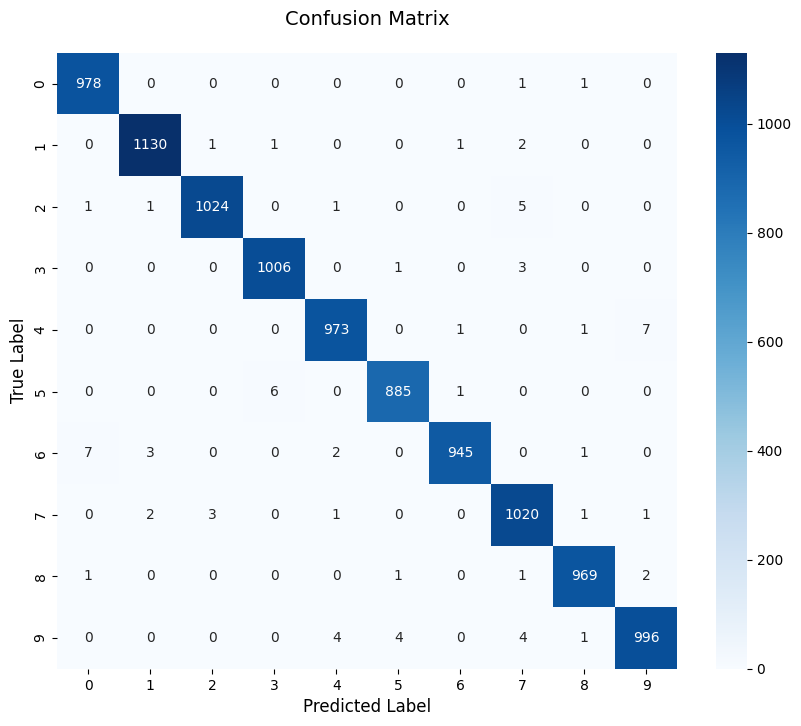

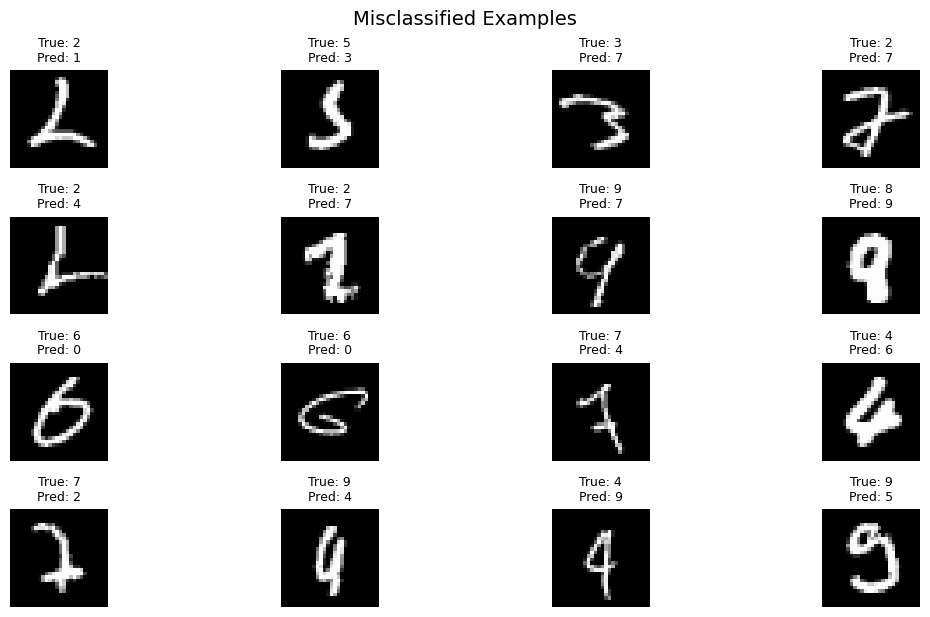

In [8]:
# 추가: 혼동 행렬 및 오답 이미지 시각화 코드

def visualize_analysis():
    # 1. 혼동 행렬 생성
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            output = model(data)
            preds = output.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(target.numpy())

    # 혼동 행렬 시각화
    plt.figure(figsize=(10,8))
    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title('Confusion Matrix', fontsize=14, pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

    # 2. 잘못 분류된 이미지 추출
    wrong_images = []
    wrong_preds = []
    wrong_labels = []

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            output = model(data)
            preds = output.argmax(dim=1)

            # 틀린 예측만 선택
            mask = preds.cpu() != target
            wrong_images.extend(data[mask].cpu().numpy())
            wrong_preds.extend(preds[mask].cpu().numpy())
            wrong_labels.extend(target[mask].numpy())

    # 3. 오답 이미지 시각화 (최대 16개)
    plt.figure(figsize=(12,6))
    for i in range(min(16, len(wrong_images))):
        plt.subplot(4,4,i+1)
        plt.imshow(wrong_images[i].squeeze(), cmap='gray')
        plt.title(f'True: {wrong_labels[i]}\nPred: {wrong_preds[i]}', fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.suptitle('Misclassified Examples', y=1.02, fontsize=14)
    plt.show()

# 분석 실행
visualize_analysis()